In [1]:

import os
#os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.98"

import jax
import jax.numpy as jnp

import numpy as np
import matplotlib.pyplot as plt
from dmri.simulators import  Ball3StickSharedDiffusivity
from dmri.simulators.acquisition_scheme import acquisition_scheme
from flax import nnx

import matplotlib.pyplot as plt

plt.style.use("../../dmri/utils/pyloric.mplstyle")
from ksd_eval import plot_violin, expand_label_masks, LABELS_MASK,build_label_masks,group_by_mask_list, trim_values,normalize_by_prior

In [2]:
path_syn = "outputs/ksd_eval/synthetic_short_ksd_per_mask.npz"
data_syn = np.load(path_syn, allow_pickle=True)
data_real = np.load("outputs/ksd_eval/real_random_short_ksd_per_mask.npz", allow_pickle=True)
data_real_sel = np.load("outputs/ksd_eval/real_selected_short_ksd_per_mask.npz", allow_pickle=True)

In [3]:
data_syn_long = np.load("outputs/ksd_eval/synthetic_long_ksd_per_mask.npz", allow_pickle=True)
data_real_long = np.load("outputs/ksd_eval/real_random_long_ksd_per_mask.npz", allow_pickle=True)
data_real_sel_long = np.load("outputs/ksd_eval/real_selected_long_ksd_per_mask.npz", allow_pickle=True)

In [4]:
data_syn["ksd"].shape

(15, 125091)

In [5]:
np.nanmean(data_syn["ksd"]) / np.nanmean(data_syn_long["ksd_prior"])

np.float32(0.0005456109)

In [6]:
np.nanmean(data_real["ksd"]) / np.nanmean(data_real_long["ksd_prior"])

np.float32(0.03426128)

In [7]:
np.nanmean(data_real_sel["ksd"]) / np.nanmean(data_real_sel_long["ksd_prior"])

np.float32(0.0010371885)

In [8]:
def preprocess(data):
    label_masks = build_label_masks(LABELS_MASK, data["mask_support"].shape[1])
    ksds_short = data["ksd"]
    ksds_short_prior = data["ksd_prior"]
    masks_short = data["mask_support"]
    mask_list, labels = expand_label_masks(label_masks)
    ksd_short_model = group_by_mask_list(ksds_short, masks_short, mask_list)
    ksd_short_prior_model = group_by_mask_list(
        ksds_short_prior, masks_short, mask_list
    )
    ksd_short_ratio = normalize_by_prior(ksd_short_model, ksd_short_prior_model)
    ksd_short_ratio = trim_values(ksd_short_ratio, 0.99)
    return ksd_short_ratio, labels

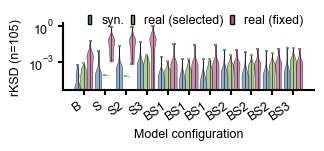

In [27]:
ksds_short_syn, labels = preprocess(data_syn)
ksds_short_real = preprocess(data_real)[0]
ksds_short_real_sel = preprocess(data_real_sel)[0]

# Collapse sticks
labels = labels[:2] + labels[6:]
ksds_short_syn = ksds_short_syn[:2] + ksds_short_syn[6:]
ksds_short_real = ksds_short_real[:2] + ksds_short_real[6:]
ksds_short_real_sel = ksds_short_real_sel[:2] + ksds_short_real_sel[6:]

fig, ax = plot_violin(
    [ksds_short_syn,ksds_short_real_sel,ksds_short_real],
    labels,
    None,
    None,
    "rKSD (n=105)",
    group_labels=["syn.",  "real (selected)","real (fixed)"],
    colors=["#608fb9","#8fb960","#b9608f"],
    figsize=(3.3, 1.8),
    violin_width=0.3,
    group_span=0.6,
    legend=True,
    legend_kwargs=dict(ncol=3, bbox_to_anchor=(1., 1.3), handlelength=0.3, columnspacing=0.5)
)
#ax.set_ylim(None, 0.3)
#ax.set_xticklabels([])
#ax.set_xlabel("")
ax.set_yscale("log")

#fig.legend(frameon=False,  ncols=3)
#fig.tight_layout()
fig.savefig("ksd_short_violin.png", dpi=300, bbox_inches='tight', transparent=True)
fig.savefig("ksd_short_violin.svg", bbox_inches='tight', transparent=True)

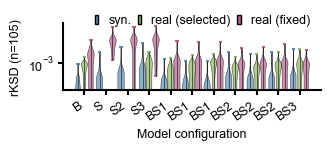

In [26]:
ksds_short_syn, labels = preprocess(data_syn_long)
ksds_short_real = preprocess(data_real_long)[0]
ksds_short_real_sel = preprocess(data_real_sel_long)[0]

# Collapse sticks
labels = labels[:2] + labels[6:]
ksds_short_syn = ksds_short_syn[:2] + ksds_short_syn[6:]
ksds_short_real = ksds_short_real[:2] + ksds_short_real[6:]
ksds_short_real_sel = ksds_short_real_sel[:2] + ksds_short_real_sel[6:]


fig, ax = plot_violin(
    [ksds_short_syn,ksds_short_real_sel,ksds_short_real],
    labels,
    None,
    None,
    "rKSD (n=105)",
    group_labels=["syn.",  "real (selected)","real (fixed)"],
    colors=["#608fb9","#8fb960","#b9608f"],
    figsize=(3.3, 1.8),
    violin_width=0.3,
    group_span=0.6,
    legend=True,
    legend_kwargs=dict(ncol=3, bbox_to_anchor=(1., 1.3), handlelength=0.3, columnspacing=0.5)
)
#ax.set_ylim(None, 0.3)
#ax.set_xticklabels([])
#ax.set_xlabel("")
ax.set_yscale("log")

#fig.legend(frameon=False,  ncols=3)
#fig.tight_layout()
fig.savefig("ksd_long_violin.png", dpi=300, bbox_inches='tight', transparent=True)
fig.savefig("ksd_long_violin.svg", bbox_inches='tight', transparent=True)

/tmp/ipykernel_2510181/3811019577.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  fig.legend(frameon=False, loc='upper center', ncol=3, bbox_to_anchor=(0.5, 0.1))


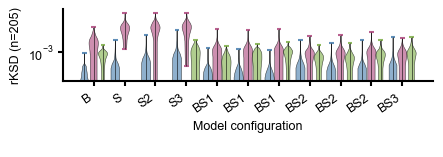

In [13]:
ksds_long_syn, labels = preprocess(data_syn_long)
ksds_long_real = preprocess(data_real_long)[0]
ksds_long_real_sel = preprocess(data_real_sel_long)[0]

# Collapse sticks
labels = labels[:2] + labels[6:]
ksds_long_syn = ksds_long_syn[:2] + ksds_long_syn[6:]
ksds_long_real = ksds_long_real[:2] + ksds_long_real[6:]
ksds_long_real_sel = ksds_long_real_sel[:2] + ksds_long_real_sel[6:]

fig, ax = plot_violin(
    [ksds_long_syn,ksds_long_real, ksds_long_real_sel],
    labels,
    None,
    None,
    "rKSD (n=205)",
    group_labels=["syn.", 'real', 'real (selected)'],
    colors=["#608fb9","#b9608f","#8fb960"],
    figsize=(4.5, 1.5),
    violin_width=0.3,
    group_span=0.6,
    legend=False,
    legend_kwargs=dict(ncol=2)
)
ax.set_yscale("log")
fig.legend(frameon=False, loc='upper center', ncol=3, bbox_to_anchor=(0.5, 0.1))
fig.tight_layout()
fig.savefig("ksd_long_violin.png", dpi=300, bbox_inches='tight', transparent=True)
fig.savefig("ksd_long_violin.svg", bbox_inches='tight', transparent=True)

In [17]:
data["mask_support"]

array([[False, False, False,  True,  True],
       [False, False,  True, False,  True],
       [False, False,  True,  True,  True],
       [False,  True, False, False,  True],
       [False,  True, False,  True,  True],
       [False,  True,  True, False,  True],
       [False,  True,  True,  True,  True],
       [ True, False, False, False,  True],
       [ True, False, False,  True,  True],
       [ True, False,  True, False,  True],
       [ True, False,  True,  True,  True],
       [ True,  True, False, False,  True],
       [ True,  True, False,  True,  True],
       [ True,  True,  True, False,  True],
       [ True,  True,  True,  True,  True]])